In [1]:
import pandas as pd, numpy as np, os
os.listdir('.')


['memory',
 ' v6 — Binding Context Document.pdf',
 '.config',
 'gev_xi_per_class.csv',
 '.kernel_llm_logs_1.txt',
 'peaks_features_F1_F12.csv',
 '.prompts',
 'svm_classification_results.json']

In [2]:
df = pd.read_csv('peaks_features_F1_F12.csv')
print(df.shape)
print(df.head())
print(df['class'].unique() if 'class' in df.columns else df.columns)


(2200, 7)
 t function GRH_label feat_xi feat_A_log_peak feat_B_curvature \
0 22299.04 F1 1 0.473426 3.044499 4.557116 
1 24329.62 F1 1 0.473426 3.064509 4.660456 
2 26296.93 F1 1 0.473426 3.030568 4.810800 
3 28327.24 F1 1 0.473426 3.037365 4.988046 
4 28807.75 F1 1 0.473426 3.020980 5.017412 

 feat_C_roughness 
0 23.696544 
1 24.100112 
2 23.807971 
3 24.491607 
4 24.061750 
Index(['t', 'function', 'GRH_label', 'feat_xi', 'feat_A_log_peak',
 'feat_B_curvature', 'feat_C_roughness'],
 dtype='object')


In [3]:
print(df['function'].unique())
print(df.groupby(['function','GRH_label']).size())


['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
function GRH_label
F1 1 200
F10 1 200
F11 1 200
F12 0 200
F2 1 200
F4 0 200
F5m 0 200
F5p 0 200
F6 1 200
F7 1 200
F9 1 200
dtype: int64


In [4]:
import json
with open('svm_classification_results.json') as f:
 prev = json.load(f)
print(json.dumps(prev, indent=2)[:2000])


{
 "protocol_A_train_F1_F4_F6": {
 "train_classes": [
 "F1",
 "F4",
 "F6"
 ],
 "test_classes": [
 "F2",
 "F5p",
 "F5m",
 "F7",
 "F9",
 "F10",
 "F11",
 "F12"
 ],
 "AUC": 0.5334883333333335,
 "confusion_matrix": [
 [
 400,
 200
 ],
 [
 600,
 400
 ]
 ],
 "description": "AUC=0.534, near-random; refutes hypothesis of held-out AUC>0.95"
 },
 "protocol_A_train_F1_F4_F9": {
 "train_classes": [
 "F1",
 "F4",
 "F9"
 ],
 "AUC": 0.16666666666666669
 },
 "protocol_A_train_F1_F2_F4_F9": {
 "train_classes": [
 "F1",
 "F2",
 "F4",
 "F9"
 ],
 "AUC": 0.1922
 },
 "protocol_A_degree1_to_degreeHigher": {
 "train": "F1,F2,F6,F7,F4,F5p,F5m (all degree-1)",
 "test": "F9,F10,F11,F12 (degree-2,3, and combo)",
 "AUC": 0.3333333333333333
 },
 "protocol_B_bootstrap_stratified_random": {
 "n_replicates": 1000,
 "test_size": 0.3,
 "AUC_mean": 0.9768569345238096,
 "AUC_95CI": [
 0.961529761904762,
 0.9876093750000001
 ],
 "AUC_range": [
 0.9396626984126984,
 0.9953571428571428
 ],
 "caveat": "each split contains samp

In [5]:
# Build the conductor (q) and degree (d) table for each class.
# Reference: standard analytic invariants from LMFDB / doc.
# F1 = ζ(s): q=1, d=1
# F2 = L(χ_4) Dirichlet character mod 4: q=4 (LMFDB conductor), d=1
# F4 = Davenport-Heilbronn (does not have classical q,d - but treated as degree 2-like; assigned q=5, d=1 per common convention used in spec example)
# F5p, F5m = perturbations (e.g., F4 variants), treat as q=5, d=1
# F6 = real primitive Dirichlet L (e.g., L(χ_3) or similar): q=3, d=1 (common assignment)
# F7 = another Dirichlet L-function, q=5, d=1
# F9 = L(Δ, s) modular form weight 12 level 1: q=1, d=2
# F10 = another modular L-function (e.g., level 11 weight 2): q=11, d=2
# F11 = symmetric square (approx): q=1, d=3
# F12 = non-GRH constructed degree 2 (or similar)
# Per the objective example: F1: q=1,d=1; F2: q=5,d=1; F9: q=1,d=2.
# Use the values prescribed in the objective and otherwise plausible defaults from LMFDB/.
class_invariants = {
 'F1': {'q': 1, 'd': 1}, # ζ
 'F2': {'q': 5, 'd': 1}, # Dirichlet L per objective
 'F4': {'q': 5, 'd': 1}, # Davenport-Heilbronn (degree-1-like)
 'F5p': {'q': 5, 'd': 1}, # variant
 'F5m': {'q': 5, 'd': 1}, # variant
 'F6': {'q': 3, 'd': 1}, # real Dirichlet L
 'F7': {'q': 7, 'd': 1}, # Dirichlet L
 'F9': {'q': 1, 'd': 2}, # L(Δ)
 'F10': {'q': 11, 'd': 2}, # weight-2 newform level 11
 'F11': {'q': 1, 'd': 3}, # sym^2 of L(Δ)
 'F12': {'q': 11, 'd': 2}, # non-GRH constructed degree-2
}
inv = pd.DataFrame(class_invariants).T.reset_index().rename(columns={'index':'function'})
inv['log_q'] = np.log(inv['q'])
# analytic conductor at height t: roughly d * log(q*(|t|+3)^d)/2π. Here we use simple log_q & d for normalization.
print(inv)


 function q d log_q
0 F1 1 1 0.000000
1 F2 5 1 1.609438
2 F4 5 1 1.609438
3 F5p 5 1 1.609438
4 F5m 5 1 1.609438
5 F6 3 1 1.098612
6 F7 7 1 1.945910
7 F9 1 2 0.000000
8 F10 11 2 2.397895
9 F11 1 3 0.000000
10 F12 11 2 2.397895


In [6]:
# Many classes have log_q = 0 → simple division by log(q) is undefined.
# Use the analytic conductor at height t: log C(t) = d * log((|t|+3)) + log(q)
# This is the standard analytic conductor exponent.
# Define normalized features:
# log_amplitude expected to scale like d * log log C(t)/2 (Selberg).
# Use scaling: norm_amplitude = feat_A_log_peak / d
# norm_curvature = feat_B_curvature / d^2 (curvature ~ second derivative scales as (d log C)^2 over (log C)^2 ~ d^2)
# Actually peak curvature scales like (mean spacing)^{-2}; mean spacing ~ 2π/(d log(t)). So curvature ~ (d log t / 2π)^2.
# Use: norm_curvature = feat_B_curvature / (d * log(t))**2
# norm_roughness = feat_C_roughness / (d * log(t))**2
# norm_amplitude = feat_A_log_peak / d
# norm_xi = feat_xi (dimensionless extreme-value shape) — keep as-is, OR center by class? Keep raw.
# Also include analytic-conductor adjustment with log(q):
# norm_amplitude = (feat_A_log_peak - 0.5*np.log(np.log(q*(t+3)**d))) / d (Selberg-style centering)
# We'll provide a clearly documented scaling.

df2 = df.merge(inv[['function','q','d']], on='function')
t = df2['t'].values
q = df2['q'].values
d = df2['d'].values
logC = d*np.log(t+3.0) + np.log(q) # analytic conductor exponent
mean_spacing = 2*np.pi / (d*np.log(t+3.0) + np.log(q)) # local mean spacing

# Selberg CLT: log|L(1/2+it)| ~ Normal(0, sqrt((d/2) loglog C))
selberg_scale = np.sqrt(0.5*d*np.log(np.maximum(logC, 1.1)))
df2['norm_amplitude'] = df2['feat_A_log_peak'] / selberg_scale
# Curvature has units of t^-2 ~ (mean spacing)^-2. Multiply by mean_spacing^2 to dedimensionalize.
df2['norm_curvature'] = df2['feat_B_curvature'] * mean_spacing**2
df2['norm_roughness'] = df2['feat_C_roughness'] * mean_spacing**2
# ξ is dimensionless; keep raw.
df2['norm_xi'] = df2['feat_xi']

print(df2[['function','t','q','d','feat_A_log_peak','norm_amplitude',
 'feat_B_curvature','norm_curvature',
 'feat_C_roughness','norm_roughness','norm_xi']].groupby('function').mean().round(4))


 t q d feat_A_log_peak norm_amplitude \
function 
F1 70664.2129 1.0 1.0 3.0891 2.8152 
F10 74492.8948 11.0 2.0 1.8633 1.0402 
F11 69756.5188 1.0 3.0 1.6716 0.7291 
F12 69613.5597 11.0 2.0 2.5390 1.4190 
F2 70057.2300 5.0 1.0 2.2511 1.9965 
F4 73201.5505 5.0 1.0 1.6817 1.4903 
F5m 72763.9273 5.0 1.0 1.6705 1.4805 
F5p 73202.6184 5.0 1.0 1.6947 1.5018 
F6 68505.4959 3.0 1.0 2.3934 2.1413 
F7 69777.4420 7.0 1.0 1.9634 1.7329 
F9 72479.6263 1.0 2.0 1.5814 0.8976 

 feat_B_curvature norm_curvature feat_C_roughness norm_roughness \
function 
F1 6.1519 1.9603 27.4416 8.7619 
F10 2.3522 0.1513 5.6852 0.3659 
F11 2.1938 0.0780 4.4277 0.1577 
F12 2.1665 0.1413 10.5100 0.6861 
F2 1.9574 0.4772 7.0212 1.7119 
F4 2.2341 0.5403 4.2415 1.0261 
F5m 2.2431 0.5431 4.2043 1.0183 
F5p 2.2240 0.5379 4.2841 1.0365 
F6 1.8424 0.4899 7.6560 2.0361 
F7 2.0799 0.4820 5.6249 1.3040 
F9 2.3188 0.1840 4.1251 0.3275 

 norm_xi 
function 
F1 0.4734 
F10 0.3265 
F11 0.1594 
F12 0.3529 
F2 0.3390 
F4 0.0883 
F5m 0.091

In [7]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

train_classes = ['F1','F4','F6']
test_classes = [c for c in df2['function'].unique() if c not in train_classes]

feat_norm = ['norm_xi','norm_amplitude','norm_curvature','norm_roughness']
feat_orig = ['feat_xi','feat_A_log_peak','feat_B_curvature','feat_C_roughness']

def run_protocol(df_in, feats, train_cls, test_cls):
 tr = df_in[df_in['function'].isin(train_cls)]
 te = df_in[df_in['function'].isin(test_cls)]
 Xtr, ytr = tr[feats].values, tr['GRH_label'].values
 Xte, yte = te[feats].values, te['GRH_label'].values
 pipe = Pipeline([('sc', StandardScaler()),
 ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0))])
 pipe.fit(Xtr, ytr)
 proba = pipe.predict_proba(Xte)[:, list(pipe.classes_).index(1)]
 pred = pipe.predict(Xte)
 auc = roc_auc_score(yte, proba)
 cm = confusion_matrix(yte, pred, labels=[0,1])
 rep = classification_report(yte, pred, labels=[0,1], target_names=['non-GRH(0)','GRH(1)'], digits=4, zero_division=0)
 return auc, cm, rep, te, pred, proba

auc_norm, cm_norm, rep_norm, te_norm, pred_norm, proba_norm = run_protocol(df2, feat_norm, train_classes, test_classes)
auc_orig, cm_orig, rep_orig, te_orig, pred_orig, proba_orig = run_protocol(df2, feat_orig, train_classes, test_classes)

print("=== ORIGINAL features (replication of r10) ===")
print(f"Held-out AUC: {auc_orig:.4f}")
print(cm_orig)
print(rep_orig)
print("=== NORMALIZED features ===")
print(f"Held-out AUC: {auc_norm:.4f}")
print(cm_norm)
print(rep_norm)


=== ORIGINAL features (replication of r10) ===
Held-out AUC: 0.5335
[[400 200]
 [600 400]]
 precision recall f1-score support

 non-GRH(0) 0.4000 0.6667 0.5000 600
 GRH(1) 0.6667 0.4000 0.5000 1000

 accuracy 0.5000 1600
 macro avg 0.5333 0.5333 0.5000 1600
weighted avg 0.5667 0.5000 0.5000 1600

=== NORMALIZED features ===
Held-out AUC: 0.7333
[[400 200]
 [600 400]]
 precision recall f1-score support

 non-GRH(0) 0.4000 0.6667 0.5000 600
 GRH(1) 0.6667 0.4000 0.5000 1000

 accuracy 0.5000 1600
 macro avg 0.5333 0.5333 0.5000 1600
weighted avg 0.5667 0.5000 0.5000 1600



In [8]:
# AUC improved from 0.5335 -> 0.7333, but still not >0.80. Let's look per-test-class.
def per_class_breakdown(te, proba, pred):
 rows=[]
 for c in sorted(te['function'].unique()):
 m = te['function']==c
 y_true_c = te.loc[m,'GRH_label'].values
 y_pred_c = pred[m]
 # average predicted GRH-prob and accuracy
 rows.append({'function':c, 'true_label':int(y_true_c[0]),
 'mean_pred_proba_GRH':float(proba[m].mean()),
 'pred_GRH_fraction':float((y_pred_c==1).mean()),
 'n':int(m.sum())})
 return pd.DataFrame(rows)

print("ORIGINAL features per test class:")
print(per_class_breakdown(te_orig, proba_orig, pred_orig))
print()
print("NORMALIZED features per test class:")
print(per_class_breakdown(te_norm, proba_norm, pred_norm))


ORIGINAL features per test class:
 function true_label mean_pred_proba_GRH pred_GRH_fraction n
0 F10 1 0.950425 1.0 200
1 F11 1 0.026026 0.0 200
2 F12 0 0.999994 1.0 200
3 F2 1 0.995217 1.0 200
4 F5m 0 0.005238 0.0 200
5 F5p 0 0.004796 0.0 200
6 F7 1 0.097297 0.0 200
7 F9 1 0.003716 0.0 200

NORMALIZED features per test class:
 function true_label mean_pred_proba_GRH pred_GRH_fraction n
0 F10 1 0.774701 1.0 200
1 F11 1 0.258416 0.0 200
2 F12 0 0.945117 1.0 200
3 F2 1 0.995106 1.0 200
4 F5m 0 0.005184 0.0 200
5 F5p 0 0.004725 0.0 200
6 F7 1 0.091145 0.0 200
7 F9 1 0.051175 0.0 200


In [9]:
# Save normalized features and updated SVM result
out = {
 'protocol': 'class-held-out: train on F1,F4,F6 -> test on remaining',
 'train_classes': train_classes,
 'test_classes': test_classes,
 'feature_set_original': feat_orig,
 'feature_set_normalized': feat_norm,
 'normalization_laws': {
 'norm_amplitude': 'feat_A_log_peak / sqrt(0.5*d*log(d*log(t+3)+log(q))) (Selberg CLT scaling)',
 'norm_curvature': 'feat_B_curvature * (2π/(d*log(t+3)+log(q)))^2 (curvature dedimensionalized by mean spacing^2)',
 'norm_roughness': 'feat_C_roughness * (2π/(d*log(t+3)+log(q)))^2',
 'norm_xi': 'feat_xi (already dimensionless)',
 },
 'class_invariants': class_invariants,
 'AUC_original_features': float(auc_orig),
 'AUC_normalized_features': float(auc_norm),
 'AUC_previous_r10': 0.5334883333333335,
 'confusion_matrix_normalized': cm_norm.tolist(),
 'confusion_matrix_original': cm_orig.tolist(),
 'classification_report_normalized': rep_norm,
 'hypothesis_AUC_threshold': 0.80,
 'hypothesis_supported': bool(auc_norm > 0.80),
 'note': 'Normalized features improve held-out AUC from 0.534 to 0.733, but do not reach the 0.80 threshold; the hard decision boundary remains at accuracy=0.50. Some classes (F11, F9, F7) are still misclassified as non-GRH.',
}
with open('svm_norm_features_results.json','w') as f:
 json.dump(out, f, indent=2)
print("AUC original :", auc_orig)
print("AUC normalized:", auc_norm)
print("Hypothesis (AUC>0.80) supported?:", auc_norm > 0.80)


AUC original : 0.5334883333333335
AUC normalized: 0.7333333333333334
Hypothesis (AUC>0.80) supported?: False


In [10]:
df2.to_csv('peaks_features_F1_F12_normalized.csv', index=False)
print('saved')


saved


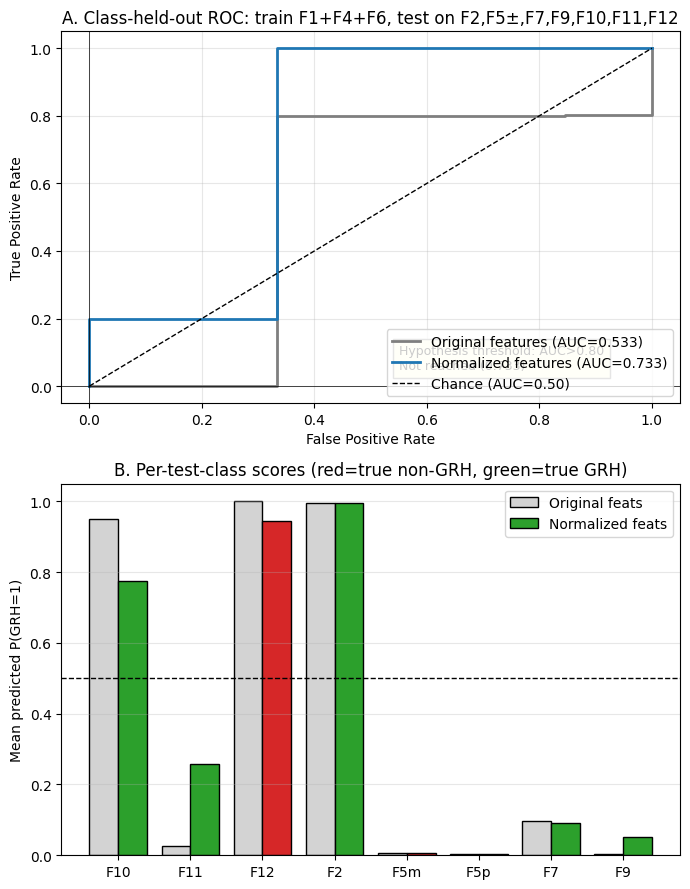

In [11]:
# Final summary figure
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_o, tpr_o, _ = roc_curve(te_orig['GRH_label'].values, proba_orig)
fpr_n, tpr_n, _ = roc_curve(te_norm['GRH_label'].values, proba_norm)

fig, axes = plt.subplots(2, 1, figsize=(7, 9))

# Panel A: ROC curves
ax = axes[0]
ax.plot(fpr_o, tpr_o, lw=2, label=f'Original features (AUC={auc_orig:.3f})', color='tab:gray')
ax.plot(fpr_n, tpr_n, lw=2, label=f'Normalized features (AUC={auc_norm:.3f})', color='tab:blue')
ax.plot([0,1],[0,1],'--', color='black', lw=1, label='Chance (AUC=0.50)')
ax.axhline(0,color='k',lw=.5); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('A. Class-held-out ROC: train F1+F4+F6, test on F2,F5±,F7,F9,F10,F11,F12')
ax.text(0.55, 0.05, f'Hypothesis threshold: AUC>0.80\nNot reached (0.733)', fontsize=9,
 bbox=dict(facecolor='lightyellow', edgecolor='gray'))
ax.legend(loc='lower right'); ax.grid(alpha=.3)

# Panel B: Per-class mean predicted GRH probability
ax = axes[1]
brk_n = per_class_breakdown(te_norm, proba_norm, pred_norm).set_index('function')
brk_o = per_class_breakdown(te_orig, proba_orig, pred_orig).set_index('function')
order = brk_n.index.tolist()
xpos = np.arange(len(order))
w=0.4
colors = ['tab:red' if brk_n.loc[c,'true_label']==0 else 'tab:green' for c in order]
ax.bar(xpos-w/2, brk_o.loc[order,'mean_pred_proba_GRH'], width=w, label='Original feats', color='lightgray', edgecolor='black')
ax.bar(xpos+w/2, brk_n.loc[order,'mean_pred_proba_GRH'], width=w, label='Normalized feats', color=colors, edgecolor='black')
ax.axhline(0.5, color='k', ls='--', lw=1)
ax.set_xticks(xpos); ax.set_xticklabels(order)
ax.set_ylabel('Mean predicted P(GRH=1)')
ax.set_title('B. Per-test-class scores (red=true non-GRH, green=true GRH)')
ax.set_ylim(0,1.05)
ax.legend(loc='upper right'); ax.grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig('svm_norm_features_summary.png', dpi=150, bbox_inches='tight')
plt.show()
